# **Data Preparation**

*Bộ train*

In [1]:
import gdown
import pandas as pd
import pathlib
# import os # Không cần thiết nếu dùng pathlib

# 1. Định nghĩa file ID và tên file bạn muốn lưu
file_id = "1-kLJbJr4cgqG9ZbJp6U_ZzGaJLSMVnWb"
output_filename = "data.csv" # Sẽ lưu file này vào cùng thư mục với script

# 2. Tạo đường dẫn file ngay tại thư mục hiện tại
# Path(output_filename) sẽ tự động trỏ vào thư mục
# nơi bạn đang chạy script Python
output_path = pathlib.Path(output_filename)

# 3. (Rất nên làm) Kiểm tra xem file đã tồn tại chưa
# Nếu chạy script nhiều lần, bạn sẽ không muốn tải lại file
if not output_path.exists():
    print(f"File '{output_filename}' không tìm thấy, đang tải từ Google Drive...")
    gdown.download(id=file_id, output=str(output_path), quiet=False)
else:
    print(f"Đã tìm thấy file '{output_filename}', sử dụng file local.")

# 4. Đọc CSV
# Logic của bạn giữ nguyên, vì output_path giờ đã trỏ đúng
df_train = pd.read_csv(output_path, sep=None, engine="python", encoding="utf-8")

print("Số dòng, cột:", df_train.shape)

# 5. Thêm print()
# Trong Colab, gõ tên biến cuối cùng sẽ tự in ra,
# nhưng trong script .py, bạn phải dùng print()
print(df_train.head())

File 'data.csv' không tìm thấy, đang tải từ Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1-kLJbJr4cgqG9ZbJp6U_ZzGaJLSMVnWb
To: /content/data.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 31.0MB/s]


Số dòng, cột: (381109, 12)
   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                 152.0       39   

   Response  
0         1  
1         0  
2         1  
3        

*Bộ test*

In [2]:
import gdown
import pandas as pd
import pathlib
# import os # Không cần thiết nếu dùng pathlib

# 1. Định nghĩa file ID và tên file bạn muốn lưu
file_id = "1OWBdcnjvXQiBGceEqSeUug5vaYBuczTN"
output_filename = "data2.csv" # Sẽ lưu file này vào cùng thư mục với script

# 2. Tạo đường dẫn file ngay tại thư mục hiện tại
# Path(output_filename) sẽ tự động trỏ vào thư mục
# nơi bạn đang chạy script Python
output_path = pathlib.Path(output_filename)

# 3. (Rất nên làm) Kiểm tra xem file đã tồn tại chưa
# Nếu chạy script nhiều lần, bạn sẽ không muốn tải lại file
if not output_path.exists():
    print(f"File '{output_filename}' không tìm thấy, đang tải từ Google Drive...")
    gdown.download(id=file_id, output=str(output_path), quiet=False)
else:
    print(f"Đã tìm thấy file '{output_filename}', sử dụng file local.")

# 4. Đọc CSV
# Logic của bạn giữ nguyên, vì output_path giờ đã trỏ đúng
df_test = pd.read_csv(output_path, sep=None, engine="python", encoding="utf-8")

print("Số dòng, cột:", df_test.shape)

# 5. Thêm print()
# Trong Colab, gõ tên biến cuối cùng sẽ tự in ra,
# nhưng trong script .py, bạn phải dùng print()
print(df_test.head())

File 'data2.csv' không tìm thấy, đang tải từ Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1OWBdcnjvXQiBGceEqSeUug5vaYBuczTN
To: /content/data2.csv
100%|██████████| 6.93M/6.93M [00:00<00:00, 38.5MB/s]


Số dòng, cột: (127037, 11)
       id Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0  381110   Male   25                1         11.0                   1   
1  381111   Male   40                1         28.0                   0   
2  381112   Male   47                1         28.0                   0   
3  381113   Male   24                1         27.0                   1   
4  381114   Male   27                1         28.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  
0    < 1 Year             No         35786.0                 152.0       53  
1    1-2 Year            Yes         33762.0                   7.0      111  
2    1-2 Year            Yes         40050.0                 124.0      199  
3    < 1 Year            Yes         37356.0                 152.0      187  
4    < 1 Year             No         59097.0                 152.0      297  


# **Data Preprocessing**

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # <-- Công cụ chính để sửa lỗi

# Giả sử SEED đã được định nghĩa
SEED = 42

# --- 1. Tạo các cột _Code (ĐÃ SỬA LỖI IntCastingNaNError) ---
# Thêm .fillna(-1) trước .astype(int) để xử lý các giá trị NaN
df_train['Gender_Code'] = df_train['Gender'].map(
    {'Male': 1, 'Female': 0}
).fillna(-1).astype(int)

df_train['Vehicle_Age_Code'] = df_train['Vehicle_Age'].map(
    {'> 2 Years': 2, '1-2 Year': 1, '< 1 Year': 0}
).fillna(-1).astype(int)

df_train['Vehicle_Damage_Code'] = df_train['Vehicle_Damage'].map(
    {'Yes': 1, 'No': 0}
).fillna(-1).astype(int)

# --- 2. Định nghĩa Features (X) và Target (y) ---
# Bỏ các cột gốc đã được mã hóa và các cột không cần thiết
drop_cols = ['id', 'Response', 'Gender', 'Vehicle_Age', 'Vehicle_Damage']
FEATURES = [col for col in df_train.columns if col not in drop_cols]
TARGET = 'Response'

X = df_train[FEATURES]
y = df_train[TARGET]

# --- 3. SỬA DATA LEAKAGE: CHIA DỮ LIỆU ĐẦU TIÊN ---
# Toàn bộ phần preprocessing từ giờ sẽ "học" (fit) trên X_train
# và "áp dụng" (transform) trên cả X_train và X_val.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y # Rất nên dùng stratify
)

print(f"Đã chia dữ liệu. Mọi xử lý từ giờ sẽ học trên {X_train.shape[0]} dòng training.")
print(f"Kích thước X_train (dữ liệu thô): {X_train.shape}")
print(f"Kích thước X_val (dữ liệu thô): {X_val.shape}")

Đã chia dữ liệu. Mọi xử lý từ giờ sẽ học trên 304887 dòng training.
Kích thước X_train (dữ liệu thô): (304887, 10)
Kích thước X_val (dữ liệu thô): (76222, 10)


In [4]:
# --- 1. Phân loại các cột trong FEATURES ---

# Cột số cần Scale (StandardScaler)
numeric_features = ['Age', 'Annual_Premium', 'Vintage']

# Cột phân loại cần Mã hóa (OneHotEncoder)
# Region_Code và Policy_Sales_Channel là category, không phải số
categorical_features = ['Region_Code', 'Policy_Sales_Channel']

# Cột đã xử lý (binary 0/1/-1), chỉ cần 'passthrough' (giữ nguyên)
passthrough_features = [
    'Gender_Code',
    'Driving_License',
    'Previously_Insured',
    'Vehicle_Age_Code',
    'Vehicle_Damage_Code'
]

# --- 2. Tạo ColumnTransformer ---
# Công cụ này sẽ áp dụng đúng phép biến đổi cho đúng cột
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    remainder='drop' # Bỏ qua các cột không được liệt kê (nếu có)
)

print("Đã tạo 'preprocessor' thành công.")
print("Đây chính là toàn bộ bước tiền xử lý của bạn, được đóng gói lại.")

Đã tạo 'preprocessor' thành công.
Đây chính là toàn bộ bước tiền xử lý của bạn, được đóng gói lại.


In [5]:
# Chúng ta sẽ import model để làm ví dụ
from xgboost import XGBClassifier

# Tính trọng số (thay thế cho SMOTE)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Tính xong scale_pos_weight (thay thế SMOTE): {scale_pos_weight:.2f}")

# Tạo Pipeline hoàn chỉnh
# Bước 1: 'preprocessor' (đã định nghĩa ở Cell 3)
# Bước 2: 'clf' (model)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Tự động chạy Cell 3
    ('clf', XGBClassifier(
        random_state=SEED,
        scale_pos_weight=scale_pos_weight, # Xử lý mất cân bằng
        n_jobs=-1,
        # ... bạn có thể thêm các tham số khác ở đây
    ))
])

print("\nĐã tạo 'xgb_pipeline' thành công!")
print("Pipeline này đã sẵn sàng để .fit() trên X_train thô.")

Tính xong scale_pos_weight (thay thế SMOTE): 7.16

Đã tạo 'xgb_pipeline' thành công!
Pipeline này đã sẵn sàng để .fit() trên X_train thô.


# **Data Training**

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # Dùng Pipeline chuẩn của sklearn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
import time # Để đo thời gian
import matplotlib.pyplot as plt


In [7]:
# --- 1. Tạo các cột _Code (ĐÃ SỬA LỖI NaN) ---
# Thêm .fillna(-1) trước .astype(int) để xử lý các giá trị NaN
df_train['Gender_Code'] = df_train['Gender'].map(
    {'Male': 1, 'Female': 0}
).fillna(-1).astype(int)

df_train['Vehicle_Age_Code'] = df_train['Vehicle_Age'].map(
    {'> 2 Years': 2, '1-2 Year': 1, '< 1 Year': 0}
).fillna(-1).astype(int)

df_train['Vehicle_Damage_Code'] = df_train['Vehicle_Damage'].map(
    {'Yes': 1, 'No': 0}
).fillna(-1).astype(int)

# --- 2. Định nghĩa Features (X) và Target (y) ---
drop_cols = ['id', 'Response', 'Gender', 'Vehicle_Age', 'Vehicle_Damage']
FEATURES = [col for col in df_train.columns if col not in drop_cols]
TARGET = 'Response'

X = df_train[FEATURES]
y = df_train[TARGET]

# --- 3. CHIA DỮ LIỆU NGAY BÂY GIỜ ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y # Rất quan trọng
)

print(f"Kích thước X_train (dữ liệu thô): {X_train.shape}")
print(f"Kích thước X_val (dữ liệu thô): {X_val.shape}")

Kích thước X_train (dữ liệu thô): (304887, 10)
Kích thước X_val (dữ liệu thô): (76222, 10)


In [8]:
# Tính scale_pos_weight cho XGBoost
# (Số lượng mẫu Âm / Số lượng mẫu Dương)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print(f"Tỷ lệ mất cân bằng (scale_pos_weight): {scale_pos_weight:.2f}")
# Con số này (khoảng 7.16) sẽ được nạp vào XGBoost

Tỷ lệ mất cân bằng (scale_pos_weight): 7.16


In [9]:
# --- 1. Phân loại các cột (Giống như trước) ---
numeric_features = ['Age', 'Annual_Premium', 'Vintage']
categorical_features = ['Region_Code', 'Policy_Sales_Channel']
passthrough_features = [
    'Gender_Code',
    'Driving_License',
    'Previously_Insured',
    'Vehicle_Age_Code',
    'Vehicle_Damage_Code'
]

# --- 2. Tạo ColumnTransformer (Bộ tiền xử lý) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    remainder='drop'
)

# --- 3. "Tuning tay" - Định nghĩa tham số tốt ---
rf_params = {
    'n_estimators': 150,
    'max_depth': 12,
    'min_samples_leaf': 10,
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1
}

xgb_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'n_jobs': -1,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'early_stopping_rounds': 20 # <-- SỬA LỖI: THAM SỐ ĐƯỢC CHUYỂN VÀO ĐÂY
}

# --- 4. Tạo Pipeline hoàn chỉnh (Preprocessor + Model) ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(**rf_params))
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(**xgb_params)) # Model sẽ được tạo với tham số early stopping
])

print("Đã tạo 2 model pipeline (RF và XGB) thành công.")
print("Các tham số RF:", rf_params)
print("Các tham số XGB:", xgb_params)

Đã tạo 2 model pipeline (RF và XGB) thành công.
Các tham số RF: {'n_estimators': 150, 'max_depth': 12, 'min_samples_leaf': 10, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Các tham số XGB: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'scale_pos_weight': np.float64(7.159039820166988), 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'eval_metric': 'logloss', 'use_label_encoder': False, 'early_stopping_rounds': 20}


In [10]:
# --- 1. Huấn luyện Random Forest ---
print("Bắt đầu training Random Forest...")
start_time = time.time()

rf_pipeline.fit(X_train, y_train)

print(f"...Hoàn thành sau {time.time() - start_time:.2f} giây")

# --- 2. Huấn luyện XGBoost ---
print("\nBắt đầu training XGBoost...")
start_time = time.time()

# 1. Biến đổi X_val trước
X_val_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_val)

# 2. Fit với eval_set
# XGBoost sẽ tự động dùng 'early_stopping_rounds' đã khai báo ở Cell 4
xgb_pipeline.named_steps['clf'].fit(
    rf_pipeline.named_steps['preprocessor'].transform(X_train), # Dữ liệu X_train đã xử lý
    y_train,
    eval_set=[(X_val_transformed, y_val)],
    # early_stopping_rounds=20, # <-- SỬA LỖI: XÓA DÒNG NÀY
    verbose=False # Giữ lại verbose
)

print(f"...Hoàn thành sau {time.time() - start_time:.2f} giây")

Bắt đầu training Random Forest...
...Hoàn thành sau 90.77 giây

Bắt đầu training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [16:53:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


...Hoàn thành sau 32.23 giây


In [11]:
# --- 1. Lấy xác suất dự đoán (probability) ---
y_pred_proba_rf = rf_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_val)[:, 1]

# --- 2. Tính AUC ---
auc_rf = roc_auc_score(y_val, y_pred_proba_rf)
auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb)

print(f"\n--- Đánh giá trên tập Validation ---")
print(f"Random Forest Validation AUC: {auc_rf:.4f}")
print(f"XGBoost Validation AUC: {auc_xgb:.4f}")

# --- 3. Hàm tìm ngưỡng F1 tốt nhất (từ code trước) ---
def find_best_threshold_f1(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
    f1_scores = f1_scores[:-1]
    thresholds = thresholds[:-1]

    best_f1_idx = np.argmax(f1_scores)
    return thresholds[best_f1_idx], f1_scores[best_f1_idx]

# --- 4. Tìm ngưỡng và tạo báo cáo ---
rf_best_thresh, rf_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_rf)
xgb_best_thresh, xgb_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_xgb)

# Store the predicted classes and best thresholds
y_pred_class_rf = (y_pred_proba_rf >= rf_best_thresh).astype(int)
y_pred_class_xgb = (y_pred_proba_xgb >= xgb_best_thresh).astype(int)

# Define the variables that were causing the NameError
y_pred_rf_opt = y_pred_class_rf
y_pred_xgb_opt = y_pred_class_xgb
threshold_rf = rf_best_thresh
threshold_xgb = xgb_best_thresh


print(f"\n--- Báo cáo cuối cùng: Random Forest ---")
print(f"Ngưỡng F1 tốt nhất = {rf_best_thresh:.4f} (cho F1 = {rf_best_f1:.4f})")
print(classification_report(y_val, y_pred_class_rf))
print(confusion_matrix(y_val, y_pred_class_rf))

print(f"\n--- Báo cáo cuối cùng: XGBoost ---")
print(f"Ngưỡng F1 tốt nhất = {xgb_best_thresh:.4f} (cho F1 = {xgb_best_f1:.4f})")
print(classification_report(y_val, y_pred_class_xgb))
print(confusion_matrix(y_val, y_pred_class_xgb))


--- Đánh giá trên tập Validation ---
Random Forest Validation AUC: 0.8504
XGBoost Validation AUC: 0.8580

--- Báo cáo cuối cùng: Random Forest ---
Ngưỡng F1 tốt nhất = 0.6609 (cho F1 = 0.4544)
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     66880
           1       0.32      0.77      0.45      9342

    accuracy                           0.77     76222
   macro avg       0.64      0.77      0.66     76222
weighted avg       0.88      0.77      0.81     76222

[[51717 15163]
 [ 2137  7205]]

--- Báo cáo cuối cùng: XGBoost ---
Ngưỡng F1 tốt nhất = 0.6746 (cho F1 = 0.4592)
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     66880
           1       0.33      0.76      0.46      9342

    accuracy                           0.78     76222
   macro avg       0.64      0.77      0.66     76222
weighted avg       0.88      0.78      0.81     76222

[[52359 14521]
 [ 2230  7112]]


In [12]:
print("--- Đánh giá trên tập TRAINING (Để kiểm tra Overfitting) ---")

# 1. Dự đoán trên tập TRAIN
y_pred_proba_rf_train = rf_pipeline.predict_proba(X_train)[:, 1]
y_pred_proba_xgb_train = xgb_pipeline.predict_proba(X_train)[:, 1]

# 2. Tính AUC trên tập TRAIN
auc_rf_train = roc_auc_score(y_train, y_pred_proba_rf_train)
auc_xgb_train = roc_auc_score(y_train, y_pred_proba_xgb_train)

print(f"Random Forest TRAIN AUC: {auc_rf_train:.4f}")
print(f"XGBoost TRAIN AUC: {auc_xgb_train:.4f}")

# 3. So sánh Train vs Validation
print("\n--- So sánh Train vs Validation ---")
print(f"RF:   Train AUC = {auc_rf_train:.4f} | Validation AUC = {auc_rf:.4f}")
print(f"XGB:  Train AUC = {auc_xgb_train:.4f} | Validation AUC = {auc_xgb:.4f}")

--- Đánh giá trên tập TRAINING (Để kiểm tra Overfitting) ---
Random Forest TRAIN AUC: 0.8547
XGBoost TRAIN AUC: 0.8657

--- So sánh Train vs Validation ---
RF:   Train AUC = 0.8547 | Validation AUC = 0.8504
XGB:  Train AUC = 0.8657 | Validation AUC = 0.8580


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import time

# --- 1. Định nghĩa tham số "Tuning tay" ---
dt_params = {
    'max_depth': 10, # Giới hạn độ sâu để tránh overfitting
    'class_weight': 'balanced', # Xử lý mất cân bằng
    'random_state': SEED
}

lr_params = {
    'solver': 'liblinear', # Solver tốt cho dữ liệu nhỏ/vừa
    'class_weight': 'balanced', # Xử lý mất cân bằng
    'random_state': SEED,
    'n_jobs': -1,
    'max_iter': 1000 # Tăng max_iter để đảm bảo hội tụ
}

# --- 2. Tạo Pipeline (Dùng lại 'preprocessor' cũ) ---
# (Biến 'preprocessor' phải có sẵn từ Cell 7 nhé)
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(**dt_params))
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(**lr_params))
])

print("Đã tạo 2 pipeline mới: Decision Tree và Logistic Regression.")

Đã tạo 2 pipeline mới: Decision Tree và Logistic Regression.


In [14]:
# --- 1. Huấn luyện Decision Tree ---
print("Bắt đầu training Decision Tree...")
start_time = time.time()
dt_pipeline.fit(X_train, y_train)
print(f"...Hoàn thành sau {time.time() - start_time:.2f} giây")

# --- 2. Huấn luyện Logistic Regression ---
print("\nBắt đầu training Logistic Regression...")
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
print(f"...Hoàn thành sau {time.time() - start_time:.2f} giây")

Bắt đầu training Decision Tree...
...Hoàn thành sau 10.62 giây

Bắt đầu training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


...Hoàn thành sau 8.15 giây


In [15]:
# --- 1. Lấy xác suất dự đoán (probability) cho 4 model ---
y_pred_proba_rf = rf_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_dt = dt_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]

# --- 2. Tính AUC cho 4 model ---
auc_rf = roc_auc_score(y_val, y_pred_proba_rf)
auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb)
auc_dt = roc_auc_score(y_val, y_pred_proba_dt)
auc_lr = roc_auc_score(y_val, y_pred_proba_lr)

# --- 3. Find the best F1 score and threshold for each model ---
rf_best_thresh, rf_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_rf)
xgb_best_thresh, xgb_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_xgb)
dt_best_thresh, dt_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_dt)
lr_best_thresh, lr_best_f1 = find_best_threshold_f1(y_val, y_pred_proba_lr)


# Store the predicted classes and best thresholds for visualization
y_pred_rf_opt = (y_pred_proba_rf >= rf_best_thresh).astype(int)
threshold_rf = rf_best_thresh

y_pred_xgb_opt = (y_pred_proba_xgb >= xgb_best_thresh).astype(int)
threshold_xgb = xgb_best_thresh

y_pred_dt_opt = (y_pred_proba_dt >= dt_best_thresh).astype(int)
threshold_dt = dt_best_thresh

y_pred_lr_opt = (y_pred_proba_lr >= lr_best_thresh).astype(int)
threshold_lr = lr_best_thresh


# --- 4. In bảng so sánh tổng kết ---
print("--- SO SÁNH HIỆU NĂNG 4 MÔ HÌNH TRÊN TẬP VALIDATION ---")
print("\n(AUC: Khả năng phân biệt 2 lớp, càng cao càng tốt)")
print(f"Random Forest:\t AUC = {auc_rf:.4f}")
print(f"XGBoost:\t AUC = {auc_xgb:.4f}")
print(f"Decision Tree:\t AUC = {auc_dt:.4f}")
print(f"Logistic Reg:\t AUC = {auc_lr:.4f}")

print("\n(F1-Score: Trung bình Precision & Recall, tìm tại ngưỡng tốt nhất)")
print(f"Random Forest:\t Best F1 = {rf_best_f1:.4f} (tại ngưỡng {rf_best_thresh:.4f})")
print(f"XGBoost:\t Best F1 = {xgb_best_f1:.4f} (tại ngưỡng {xgb_best_thresh:.4f})")
print(f"Decision Tree:\t Best F1 = {dt_best_f1:.4f} (tại ngưỡng {dt_best_thresh:.4f})")
print(f"Logistic Reg:\t Best F1 = {lr_best_f1:.4f} (tại ngưỡng {lr_best_thresh:.4f})")

--- SO SÁNH HIỆU NĂNG 4 MÔ HÌNH TRÊN TẬP VALIDATION ---

(AUC: Khả năng phân biệt 2 lớp, càng cao càng tốt)
Random Forest:	 AUC = 0.8504
XGBoost:	 AUC = 0.8580
Decision Tree:	 AUC = 0.8479
Logistic Reg:	 AUC = 0.8497

(F1-Score: Trung bình Precision & Recall, tìm tại ngưỡng tốt nhất)
Random Forest:	 Best F1 = 0.4544 (tại ngưỡng 0.6609)
XGBoost:	 Best F1 = 0.4592 (tại ngưỡng 0.6746)
Decision Tree:	 Best F1 = 0.4521 (tại ngưỡng 0.6918)
Logistic Reg:	 Best F1 = 0.4540 (tại ngưỡng 0.6745)


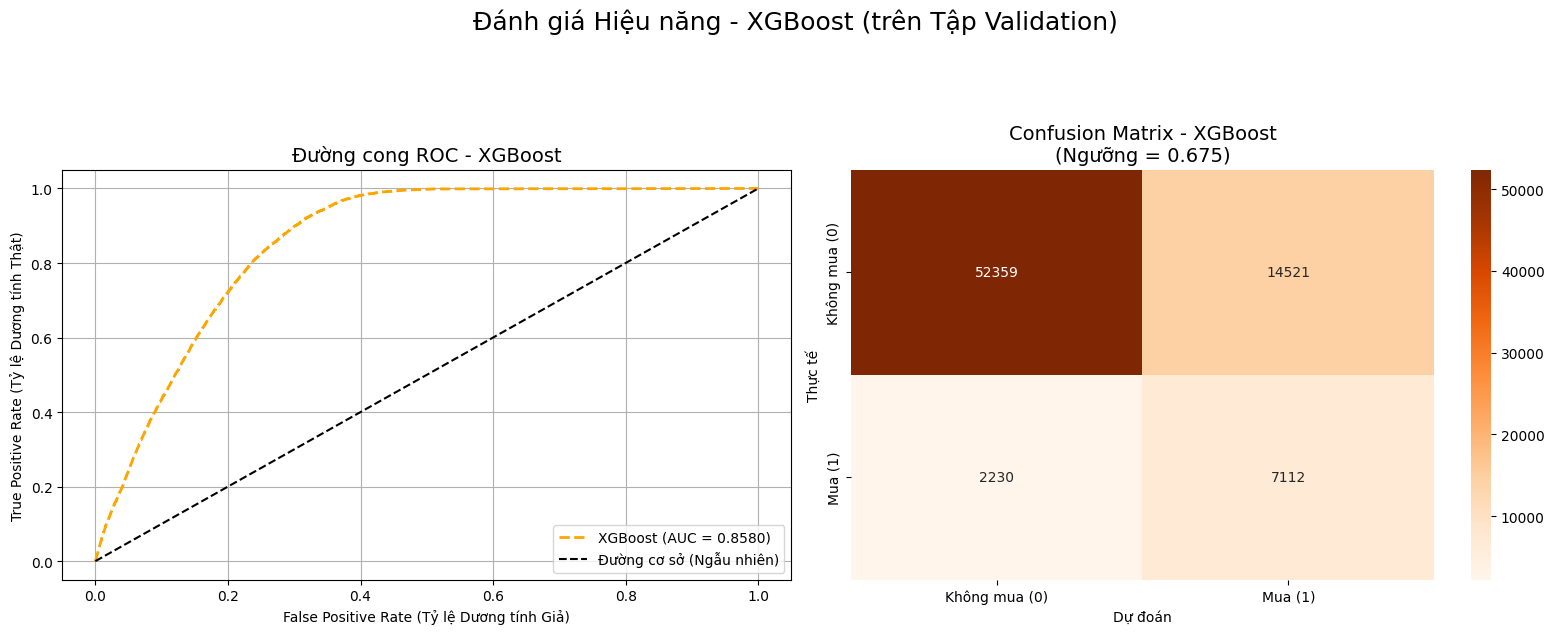

In [16]:
# --- 3. Visualize cho XGBoost ---
import seaborn as sns
from sklearn.metrics import roc_curve # <-- Thêm dòng này để import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Đánh giá Hiệu năng - XGBoost (trên Tập Validation)', fontsize=18, y=1.05)

# --- 3a. Biểu đồ ROC Curve (XGBoost) ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_proba_xgb)

ax = axes[0]
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', lw=2, color='orange', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', label='Đường cơ sở (Ngẫu nhiên)')
ax.set_title('Đường cong ROC - XGBoost', fontsize=14)
ax.set_xlabel('False Positive Rate (Tỷ lệ Dương tính Giả)')
ax.set_ylabel('True Positive Rate (Tỷ lệ Dương tính Thật)')
ax.legend()
ax.grid(True)

# --- 3b. Ma trận nhầm lẫn (Confusion Matrix) (XGBoost) ---
# (Sử dụng y_pred_xgb_opt đã tính ở cell trước)
cm_xgb = confusion_matrix(y_val, y_pred_xgb_opt)

ax = axes[1]
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Không mua (0)', 'Mua (1)'],
            yticklabels=['Không mua (0)', 'Mua (1)'])
ax.set_title(f'Confusion Matrix - XGBoost\n(Ngưỡng = {threshold_xgb:.3f})', fontsize=14)
ax.set_xlabel('Dự đoán')
ax.set_ylabel('Thực tế')

# Tinh chỉnh layout và hiển thị
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

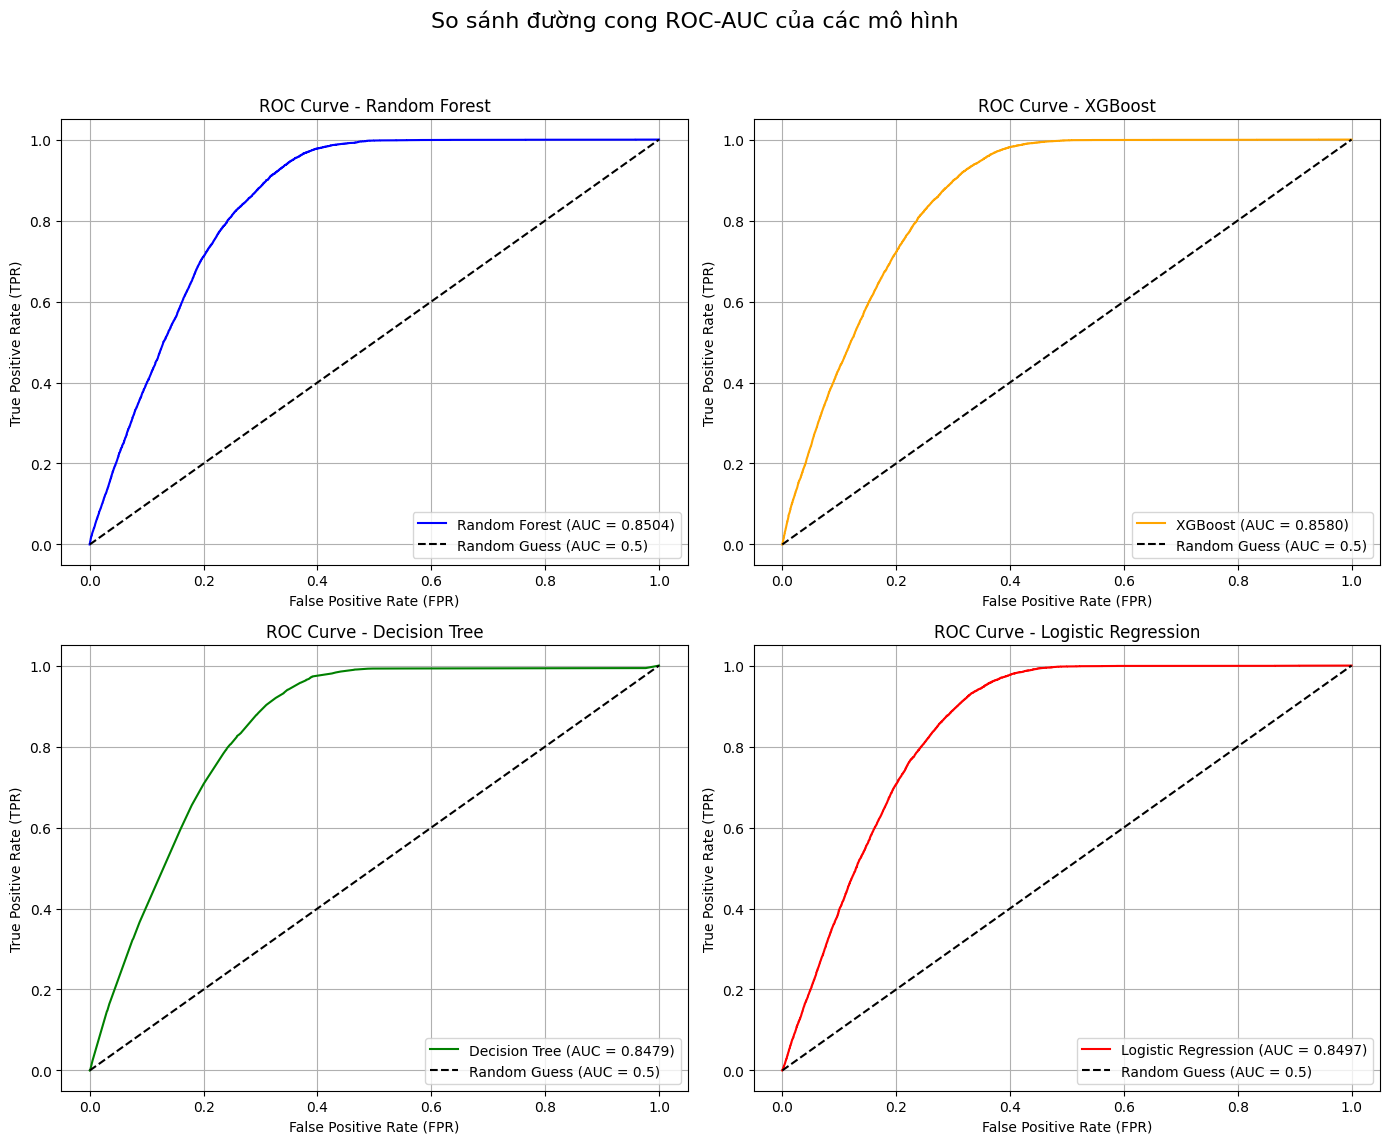

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Lấy xác suất dự đoán (cho lớp 1) từ các mô hình trên tập validation
# (Phần này giữ nguyên code của bạn)
y_pred_proba_rf = rf_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_dt = dt_pipeline.predict_proba(X_val)[:, 1]
y_pred_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]


# 2. Tính toán (FPR, TPR) và diện tích (AUC) cho từng mô hình
# (Phần này giữ nguyên code của bạn)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_proba_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_dt, tpr_dt, _ = roc_curve(y_val, y_pred_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# 3. Vẽ 4 biểu đồ ROC trên một lưới 2x2
# (Đây là phần code được thay đổi)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('So sánh đường cong ROC-AUC của các mô hình', fontsize=16)

# --- Biểu đồ 1: Random Forest ---
ax1 = axes[0, 0]
ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='blue')
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('ROC Curve - Random Forest')
ax1.legend()
ax1.grid(True)

# --- Biểu đồ 2: XGBoost ---
ax2 = axes[0, 1]
ax2.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='orange')
ax2.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
ax2.set_xlabel('False Positive Rate (FPR)')
ax2.set_ylabel('True Positive Rate (TPR)')
ax2.set_title('ROC Curve - XGBoost')
ax2.legend()
ax2.grid(True)

# --- Biểu đồ 3: Decision Tree ---
ax3 = axes[1, 0]
ax3.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', color='green')
ax3.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
ax3.set_xlabel('False Positive Rate (FPR)')
ax3.set_ylabel('True Positive Rate (TPR)')
ax3.set_title('ROC Curve - Decision Tree')
ax3.legend()
ax3.grid(True)

# --- Biểu đồ 4: Logistic Regression ---
ax4 = axes[1, 1]
ax4.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='red')
ax4.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
ax4.set_xlabel('False Positive Rate (FPR)')
ax4.set_ylabel('True Positive Rate (TPR)')
ax4.set_title('ROC Curve - Logistic Regression')
ax4.legend()
ax4.grid(True)

# Tự động điều chỉnh khoảng cách cho đẹp
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [18]:
# --- 1. Áp dụng ngưỡng cho Decision Tree ---

y_pred_class_dt = (y_pred_proba_dt >= dt_best_thresh).astype(int)



print("\n--- Báo cáo cuối cùng: Decision Tree (với ngưỡng F1) ---")

print(classification_report(y_val, y_pred_class_dt))



# --- 2. Áp dụng ngưỡng cho Logistic Regression ---

y_pred_class_lr = (y_pred_proba_lr >= lr_best_thresh).astype(int)



print("\n--- Báo cáo cuối cùng: Logistic Regression (với ngưỡng F1) ---")

print(classification_report(y_val, y_pred_class_lr))


--- Báo cáo cuối cùng: Decision Tree (với ngưỡng F1) ---
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     66880
           1       0.32      0.78      0.45      9342

    accuracy                           0.77     76222
   macro avg       0.64      0.77      0.65     76222
weighted avg       0.88      0.77      0.80     76222


--- Báo cáo cuối cùng: Logistic Regression (với ngưỡng F1) ---
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     66880
           1       0.32      0.77      0.45      9342

    accuracy                           0.77     76222
   macro avg       0.64      0.77      0.66     76222
weighted avg       0.88      0.77      0.81     76222




--- Báo cáo cuối cùng: Decision Tree (với ngưỡng F1) ---
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     66880
           1       0.32      0.78      0.45      9342

    accuracy                           0.77     76222
   macro avg       0.64      0.77      0.65     76222
weighted avg       0.88      0.77      0.80     76222


--- Báo cáo cuối cùng: Logistic Regression (với ngưỡng F1) ---
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     66880
           1       0.32      0.77      0.45      9342

    accuracy                           0.77     76222
   macro avg       0.64      0.77      0.66     76222
weighted avg       0.88      0.77      0.81     76222



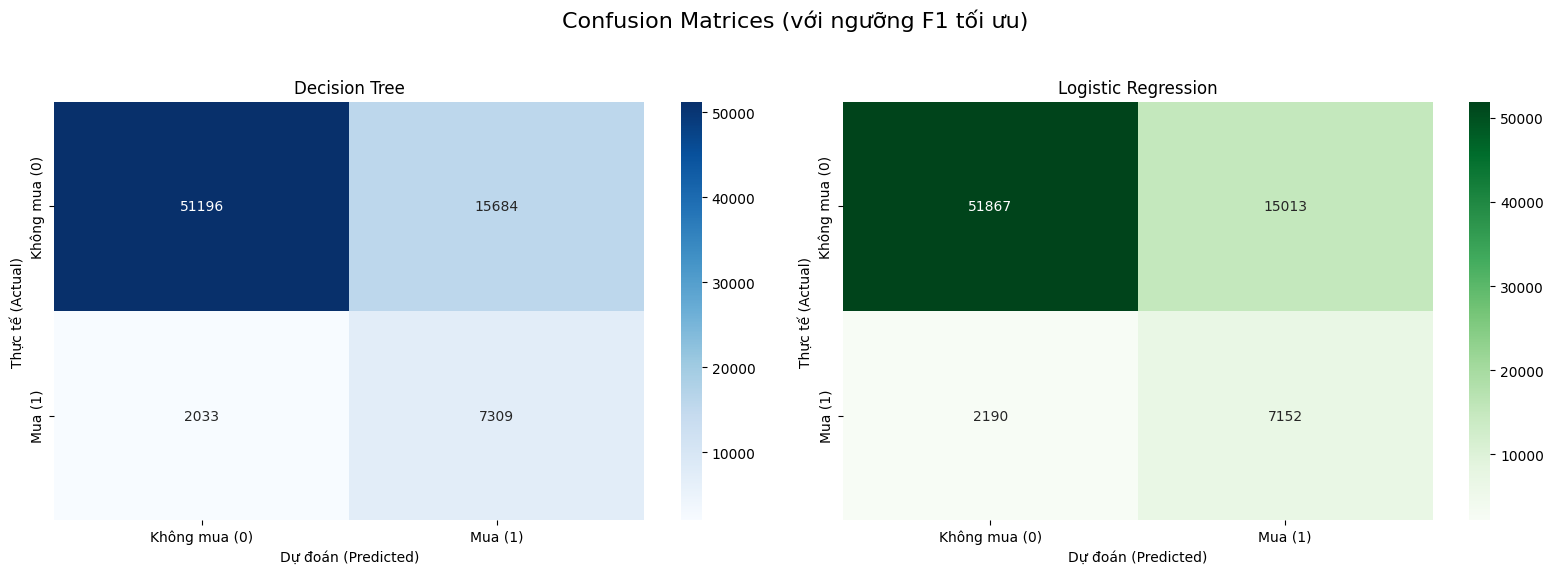

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Áp dụng ngưỡng cho Decision Tree ---
y_pred_class_dt = (y_pred_proba_dt >= dt_best_thresh).astype(int)

print("\n--- Báo cáo cuối cùng: Decision Tree (với ngưỡng F1) ---")
print(classification_report(y_val, y_pred_class_dt))

# --- 2. Áp dụng ngưỡng cho Logistic Regression ---
y_pred_class_lr = (y_pred_proba_lr >= lr_best_thresh).astype(int)

print("\n--- Báo cáo cuối cùng: Logistic Regression (với ngưỡng F1) ---")
print(classification_report(y_val, y_pred_class_lr))

# --- 3. BỔ SUNG: Tính toán Confusion Matrices ---
cm_dt = confusion_matrix(y_val, y_pred_class_dt)
cm_lr = confusion_matrix(y_val, y_pred_class_lr)

# --- 4. BỔ SUNG: Vẽ Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices (với ngưỡng F1 tối ưu)', fontsize=16)

# Labels cho các trục
labels = ['Không mua (0)', 'Mua (1)']

# Ma trận cho Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Dự đoán (Predicted)')
axes[0].set_ylabel('Thực tế (Actual)')

# Ma trận cho Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Dự đoán (Predicted)')
axes[1].set_ylabel('Thực tế (Actual)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [20]:
# --- CHỌN MÔ HÌNH TỐT NHẤT THEO AUC (tie-break bằng F1) ---
import joblib

scores = {
    "xgb": {"auc": auc_xgb, "f1": xgb_best_f1, "pipe": xgb_pipeline},
    "rf":  {"auc": auc_rf,  "f1": rf_best_f1,  "pipe": rf_pipeline},
    "dt":  {"auc": auc_dt,  "f1": dt_best_f1,  "pipe": dt_pipeline},
    "lr":  {"auc": auc_lr,  "f1": lr_best_f1,  "pipe": lr_pipeline},
}

# sắp xếp theo (-AUC, -F1)
best_name, best_info = sorted(
    scores.items(), key=lambda kv: ( -kv[1]["auc"], -kv[1]["f1"] )
)[0]

best_model = best_info["pipe"]
print(f"\n BEST MODEL: {best_name.upper()} | AUC={best_info['auc']:.4f} | F1*={best_info['f1']:.4f}")

# lưu pipeline tốt nhất để apply
joblib.dump(best_model, "best_model_pipeline.joblib")


 BEST MODEL: XGB | AUC=0.8580 | F1*=0.4592


['best_model_pipeline.joblib']

/tmp/ipython-input-2665629906.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-2665629906.py:77: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # Tự động căn chỉnh
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


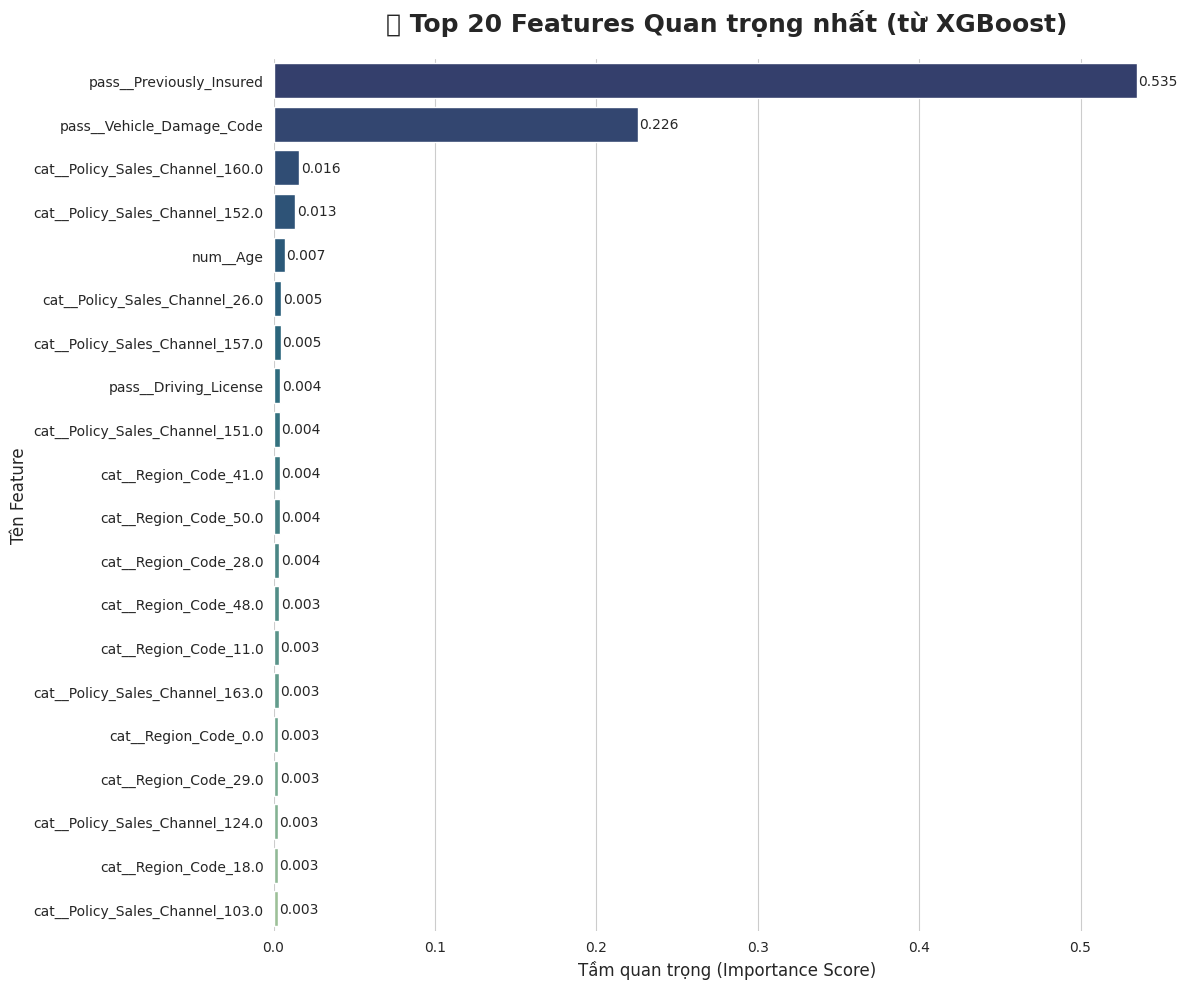

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Lấy mô hình và Preprocessor từ Pipeline ---
try:
    xgb_model = xgb_pipeline.named_steps['clf']
    preprocessor = xgb_pipeline.named_steps['preprocessor']
except NameError:
    print("LỖI: Không tìm thấy 'xgb_pipeline'.")
    print("Vui lòng đảm bảo bạn đã chạy cell huấn luyện XGBoost trước.")
    # Dừng cell nếu chưa train model
    raise

# --- 2. Lấy tên Features (Quan trọng) ---
# Dùng .get_feature_names_out() để lấy tên sau khi OneHotEncode
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError as e:
    print(f"Lỗi khi lấy tên feature: {e}")
    print("Hãy chắc chắn bạn đang dùng scikit-learn phiên bản 1.0 trở lên.")
    print("Đang thử cách cũ hơn (ít tin cậy hơn)...")

    # Cách dự phòng cho sklearn phiên bản cũ
    # Lấy tên từ OneHotEncoder
    ohe_categories = preprocessor.named_transformers_['cat'].categories_
    ohe_feature_names = []
    for i, cats in enumerate(ohe_categories):
        # Lấy tên cột gốc từ list 'categorical_features'
        original_col_name = categorical_features[i]
        ohe_feature_names.extend([f"{original_col_name}_{cat}" for cat in cats])

    # Kết hợp tất cả các tên
    feature_names = numeric_features + ohe_feature_names + passthrough_features


# --- 3. Tạo DataFrame (Feature + Importance) ---
importances = xgb_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# --- 4. Sắp xếp và lấy Top 20 ---
df_importance_sorted = df_importance.sort_values(by='Importance', ascending=False)
top_n = 20
df_top_importance = df_importance_sorted.head(top_n)

# --- 5. Vẽ Biểu đồ ---
plt.figure(figsize=(12, 10)) # Tăng kích thước cho dễ đọc
sns.set_style("whitegrid") # Đặt style nền trắng có lưới

# Sử dụng palette màu 'viridis' hoặc 'crest' (xanh lá)
# palette="viridis", palette="crest_r"
ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=df_top_importance,
    palette="crest_r" # Màu xanh lá cây đậm dần
)

# Thêm tiêu đề và nhãn
ax.set_title(f'🏆 Top {top_n} Features Quan trọng nhất (từ XGBoost)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Tầm quan trọng (Importance Score)', fontsize=12)
ax.set_ylabel('Tên Feature', fontsize=12)

# Thêm giá trị (label) trên mỗi thanh
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.001,  # Vị trí x (ngoài cùng của thanh + 1 chút)
            p.get_y() + p.get_height() / 2, # Vị trí y (giữa thanh)
            f'{width:.3f}', # Giá trị, làm tròn 3 số lẻ
            va='center')

sns.despine(left=True, bottom=True) # Xóa các đường viền
plt.tight_layout() # Tự động căn chỉnh
plt.show()

/tmp/ipython-input-945822178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_response.index, y=channel_response.values, palette='viridis')


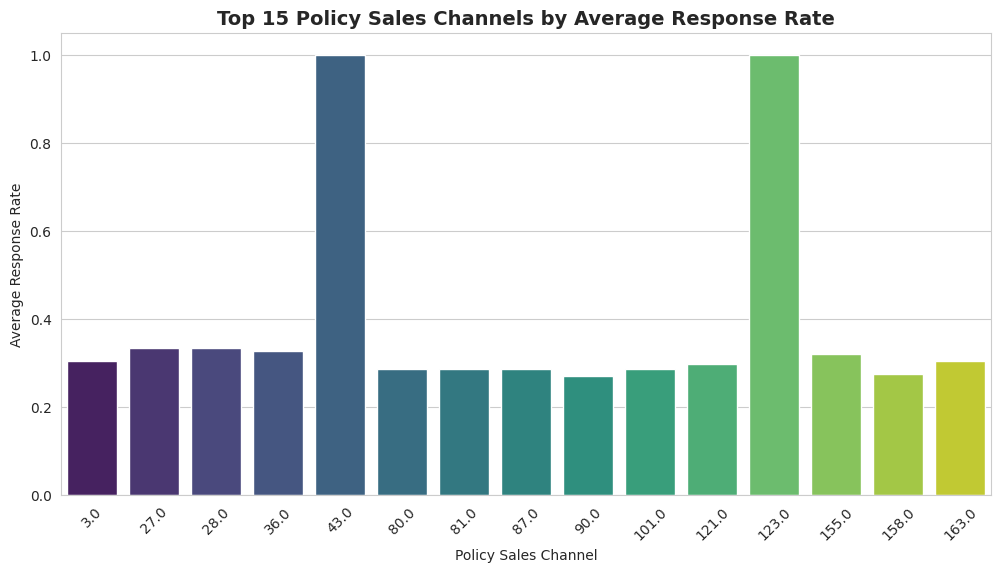

In [22]:
plt.figure(figsize=(12,6))
channel_response = df_train.groupby('Policy_Sales_Channel')['Response'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=channel_response.index, y=channel_response.values, palette='viridis')
plt.title('Top 15 Policy Sales Channels by Average Response Rate', fontsize=14, fontweight='bold')
plt.xlabel('Policy Sales Channel')
plt.ylabel('Average Response Rate')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1738054539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


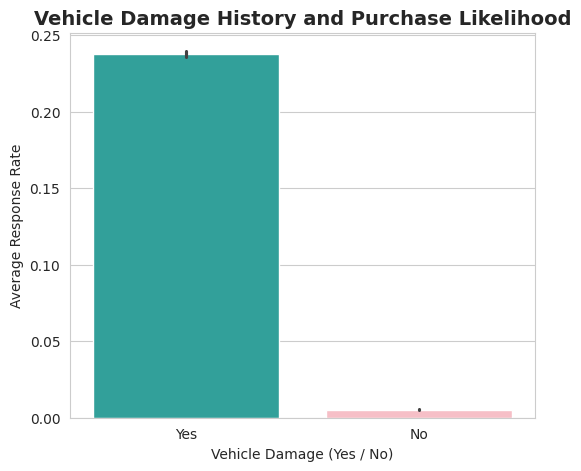

In [23]:

plt.figure(figsize=(6,5))
sns.barplot(
    x='Vehicle_Damage',
    y='Response',
    data=df_train,
    palette=['#20B2AA', '#FFB6C1']
)
plt.title('Vehicle Damage History and Purchase Likelihood', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Damage (Yes / No)')
plt.ylabel('Average Response Rate')
plt.show()

/tmp/ipython-input-262942328.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(


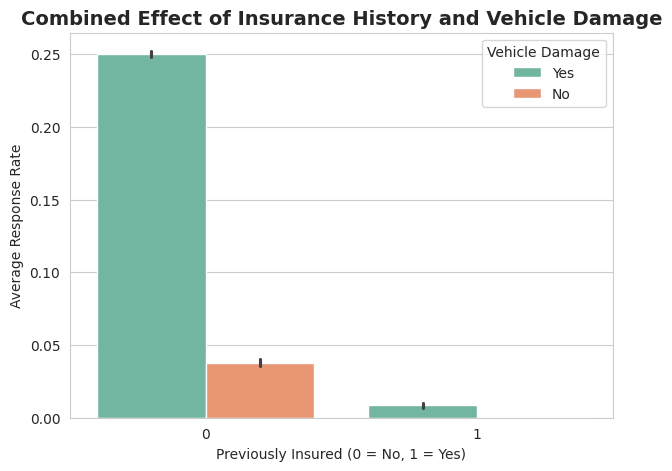

In [24]:
plt.figure(figsize=(7,5))
sns.barplot(
    x='Previously_Insured',
    y='Response',
    hue='Vehicle_Damage',
    data=df_train,
    palette=sns.color_palette("Set2")
)
plt.title('Combined Effect of Insurance History and Vehicle Damage', fontsize=14, fontweight='bold')
plt.xlabel('Previously Insured (0 = No, 1 = Yes)')
plt.ylabel('Average Response Rate')
plt.legend(title='Vehicle Damage')
plt.show()

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
sns.barplot(
    data=df_train,
    x='AgeGroup',
    y='Annual_Premium',
    hue='Response',
    palette = ['#FFB7B2', '#B2DFDB']  # xanh dương đậm & xanh ngọc sáng
)

plt.title('Average Annual Premium by Age Group and Purchase Response',
          fontsize=14, fontweight='bold', color='#073B4C')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Annual Premium (VND)', fontsize=12)
plt.legend(title='Response (1 = Purchased)', frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `AgeGroup` for `x`. An entry with this name does not appear in `data`.

<Figure size 900x600 with 0 Axes>

# **Apply data prediction**

In [26]:
# --- Import các thư viện cần thiết ---
# (Đảm bảo pandas và joblib đã được import ở các cell trước)
# import pandas as pd
# import joblib

# --- Tải mô hình và chuẩn bị dữ liệu ---
# Tải lại pipeline mô hình tốt nhất
best_model = joblib.load("best_model_pipeline.joblib")
print("Đã tải mô hình tốt nhất (XGBoost pipeline).")

# Đồng bộ schema giữa X_test và X_train (tạo X_test từ df_test)
X_test = df_test.reindex(columns=X_train.columns, fill_value=0)

# --- 1. Dự đoán XÁC SUẤT (Probability) ---
y_pred_prob_test = best_model.predict_proba(X_test)[:, 1]
df_result = pd.DataFrame({'CustomerID': X_test.index, 'Predicted_Probability': y_pred_prob_test})

# --- 2. Áp dụng NGƯỠNG TỐI ƯU (Optimized Threshold) ---
# (Giả định biến 'threshold_xgb' đã được tính)
df_result['Predicted_Class_Optimized'] = (df_result['Predicted_Probability'] >= threshold_xgb).astype(int)

# --- 3. Áp dụng PHÂN KHÚC NGHIỆP VỤ (Business Segmentation) ---
def segment_customer(prob):
    if prob >= 0.7:
        return "High Potential"
    elif prob >= 0.5:
        return "Medium Potential"
    else:
        return "Low Potential"

df_result['Segment'] = df_result['Predicted_Probability'].apply(segment_customer)

# --- 4. Xếp hạng (Rank) ---
df_result['Rank'] = df_result['Predicted_Probability'].rank(ascending=False).astype(int)
df_result = df_result[['CustomerID', 'Predicted_Probability', 'Rank', 'Predicted_Class_Optimized', 'Segment']]

# --- 5. Hiển thị kết quả tổng quan (Định dạng Bảng) ---

print("\n" + "="*80)
print("--- BẢNG 1: KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST (TOP 10) ---")
print("="*80)
# Sử dụng to_markdown để in ra bảng đẹp
print(df_result.head(10).to_markdown(index=False, numalign="left", stralign="left"))


print("\n" + "="*80)
print("--- BẢNG 2: THỐNG KÊ XÁC SUẤT DỰ ĐOÁN (Predicted_Probability) ---")
print("="*80)
stats_df = df_result['Predicted_Probability'].describe().round(4).to_frame()
stats_df.columns = ['Giá trị']
print(stats_df.to_markdown(numalign="left", stralign="left"))


print("\n" + "="*80)
print(f"--- BẢNG 3: PHÂN BỐ DỰ ĐOÁN TỐI ƯU (Ngưỡng F1 = {threshold_xgb:.4f}) ---")
print("="*80)
optimal_counts = df_result['Predicted_Class_Optimized'].value_counts().sort_index()
optimal_perc = df_result['Predicted_Class_Optimized'].value_counts(normalize=True).sort_index().mul(100).round(2)
optimal_df = pd.DataFrame({
    'Dự đoán (Class)': optimal_counts.index.map({0: '0 (Không Mua)', 1: '1 (Mua)'}),
    'Số lượng (Count)': optimal_counts.values,
    'Tỷ lệ (Percentage)': optimal_perc.values
})
optimal_df['Tỷ lệ (Percentage)'] = optimal_df['Tỷ lệ (Percentage)'].astype(str) + ' %'
print(optimal_df.to_markdown(index=False, numalign="left", stralign="left"))


print("\n" + "="*80)
print("--- BẢNG 4: PHÂN BỐ PHÂN KHÚC NGHIỆP VỤ (Ngưỡng 0.7 & 0.5) ---")
print("="*80)
segment_counts = df_result['Segment'].value_counts()
segment_perc = df_result['Segment'].value_counts(normalize=True).mul(100).round(2)
segment_df = pd.DataFrame({
    'Phân khúc (Segment)': segment_counts.index,
    'Số lượng (Count)': segment_counts.values,
    'Tỷ lệ (Percentage)': segment_perc.loc[segment_counts.index].values
})
segment_df['Tỷ lệ (Percentage)'] = segment_df['Tỷ lệ (Percentage)'].astype(str) + ' %'
# Sắp xếp theo thứ tự logic High -> Medium -> Low
segment_order = ["High Potential", "Medium Potential", "Low Potential"]
segment_df = segment_df.set_index('Phân khúc (Segment)').reindex(segment_order).reset_index()
print(segment_df.to_markdown(index=False, numalign="left", stralign="left"))
print("="*80)

Đã tải mô hình tốt nhất (XGBoost pipeline).

--- BẢNG 1: KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST (TOP 10) ---
| CustomerID   | Predicted_Probability   | Rank   | Predicted_Class_Optimized   | Segment       |
|:-------------|:------------------------|:-------|:----------------------------|:--------------|
| 0            | 0.00409909              | 88242  | 0                           | Low Potential |
| 1            | 0.336955                | 14991  | 0                           | Low Potential |
| 2            | 0.287306                | 27557  | 0                           | Low Potential |
| 3            | 0.00995743              | 71876  | 0                           | Low Potential |
| 4            | 0.00289564              | 98550  | 0                           | Low Potential |
| 5            | 0.00147523              | 124724 | 0                           | Low Potential |
| 6            | 0.0050805               | 82013  | 0                           | Low Potential |
| 7            | 0

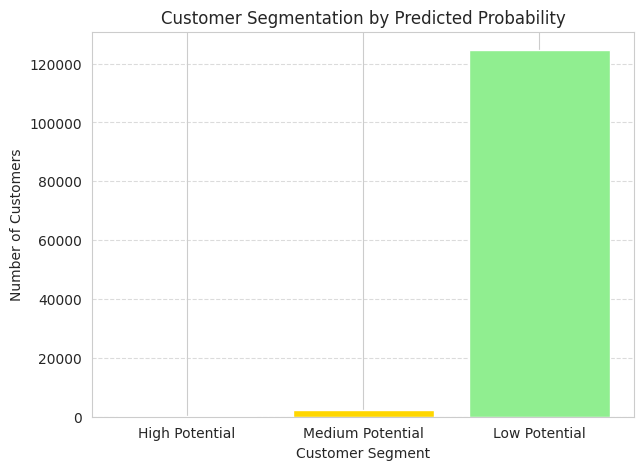

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tạo dữ liệu thủ công dựa trên bảng kết quả
data = {
    'Segment': ['High Potential', 'Medium Potential', 'Low Potential'],
    'Customer_Count': [100, 2319, 124610],
    'Percentage': [0.09, 1.83, 98.09] # Cột này không dùng để vẽ, nhưng thêm vào cho đủ
}

# 2. Tạo DataFrame tên là segment_summary
segment_summary = pd.DataFrame(data)

# VẼ BIỂU ĐỒ CỘT – PHÂN BỔ KHÁCH HÀNG THEO NHÓM
plt.figure(figsize=(7,5))
plt.bar(segment_summary["Segment"], segment_summary["Customer_Count"],
        color=['lightcoral', 'gold', 'lightgreen'])
plt.title("Customer Segmentation by Predicted Probability")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [28]:
# --- CODE MỚI THAY THẾ CHO PHẦN PRINT ---

# Cần import thư viện display
from IPython.display import display, HTML

print("Top high potential customers preview:")

# Lấy 108 khách hàng tiềm năng cao nhất
top_customers = df_result[df_result['Segment'] == 'High Potential'].copy()

# Add the 'Age' column to the top_customers DataFrame
top_customers['Age'] = df_test.loc[top_customers['CustomerID'], 'Age'].values

# Lấy 10 khách hàng đầu tiên
df_display = top_customers.head(10)


# Sử dụng Styler API để làm đẹp
styled_df = df_display.style \
    .format({
        'Annual_Premium': '{:,.0f} VND',  # Thêm dấu phẩy ngăn cách hàng ngàn
        'Predicted_Probability': '{:.2%}'   # Hiển thị dạng % với 2 số lẻ
    }) \
    .background_gradient(cmap='Greens', subset=['Predicted_Probability']) \
    .bar(subset=['Age'], color='#cce5ff', vmin=18) \
    .set_caption(" Top 10 Khách hàng Tiềm năng cao nhất ") \
    .hide(axis="index") \
    .set_table_styles([
        # Style cho header (tiêu đề cột)
        {'selector': 'th', 'props': [
            ('background-color', '#004d00'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('font-size', '14px')
        ]},
        # Style cho caption (tiêu đề bảng)
        {'selector': 'caption', 'props': [
            ('color', 'black'),
            ('font-size', '18px'),
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]},
        # Style cho ô dữ liệu
        {'selector': 'td', 'props': [
            ('text-align', 'center')
        ]}
    ])

# Hiển thị bảng đã được làm đẹp
display(styled_df)

Top high potential customers preview:


CustomerID,Predicted_Probability,Rank,Predicted_Class_Optimized,Segment,Age
2303,72.26%,68,1,High Potential,51
3485,70.70%,100,1,High Potential,39
4639,75.47%,17,1,High Potential,39
5135,72.43%,63,1,High Potential,38
6621,75.52%,16,1,High Potential,45
8269,73.23%,43,1,High Potential,42
11707,72.82%,53,1,High Potential,33
12611,71.63%,79,1,High Potential,32
13100,79.07%,6,1,High Potential,42
13176,71.55%,88,1,High Potential,41


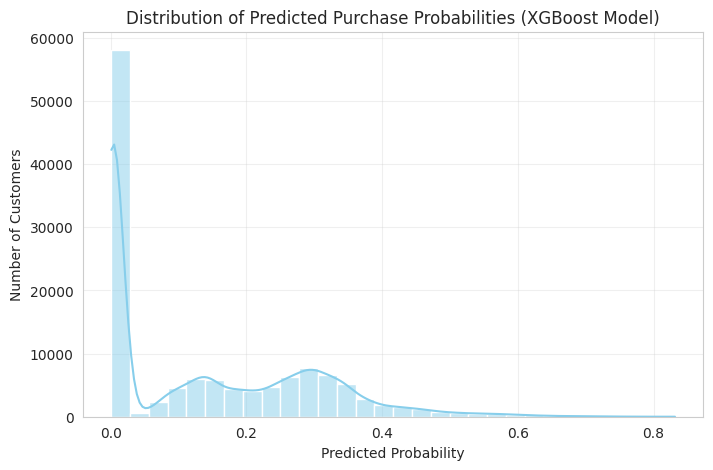

In [29]:
import seaborn as sns

# VẼ BIỂU ĐỒ PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN
plt.figure(figsize=(8,5))
sns.histplot(df_result["Predicted_Probability"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Predicted Purchase Probabilities (XGBoost Model)")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()


--- Biểu đồ Cumulative Gains Chart (XGBoost) ---


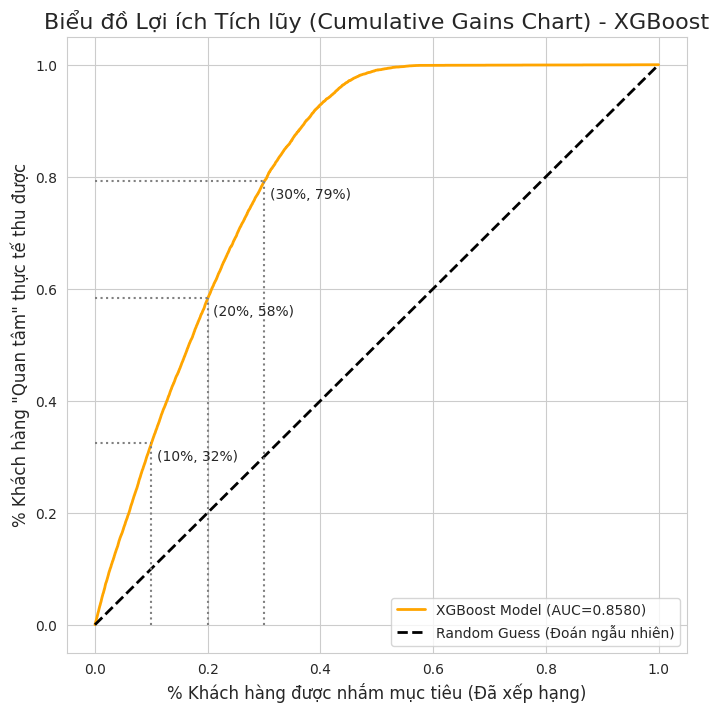


--- Bảng Phân tích Decile (XGBoost) ---
| Decile (Nhóm)   | # Khách hàng   | # KH Quan tâm   | % KH Quan tâm (trong nhóm)   | % Tích lũy   | Lift (Độ nâng)   |
|:----------------|:---------------|:----------------|:-----------------------------|:-------------|:-----------------|
| 1               | 7623           | 3025            | 32.38%                       | 32.38%       | 3.24x            |
| 2               | 7623           | 2422            | 25.93%                       | 58.31%       | 2.59x            |
| 3               | 7622           | 1947            | 20.84%                       | 79.15%       | 2.08x            |
| 4               | 7622           | 1280            | 13.70%                       | 92.85%       | 1.37x            |
| 5               | 7622           | 578             | 6.19%                        | 99.04%       | 0.62x            |
| 6               | 7622           | 80              | 0.86%                        | 99.89%       | 0.09x            |

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- PHÂN TÍCH LỢI ÍCH (GAINS CHART & DECILE) CHO MÔ HÌNH TỐT NHẤT (XGBOOST) ---

# 1. Tạo DataFrame kết hợp y_val (thực tế) và y_pred_proba_xgb (xác suất dự đoán)
# (Giả định các biến này đã tồn tại từ các cell huấn luyện trước đó)
try:
    df_val_results = pd.DataFrame({
        'y_true': y_val,
        'prob_xgb': y_pred_proba_xgb
    })
except NameError:
    print("Lỗi: Không tìm thấy biến 'y_val' hoặc 'y_pred_proba_xgb'.")
    print("Vui lòng chạy lại các cell trong phần 'Data Training' trước.")
    raise

# 2. Sắp xếp theo xác suất dự đoán (giảm dần)
df_sorted = df_val_results.sort_values(by='prob_xgb', ascending=False)

# 3. Tính toán các giá trị tích lũy
total_positives = df_sorted['y_true'].sum()
total_population = len(df_sorted)

df_sorted['cumulative_gains'] = df_sorted['y_true'].cumsum()
df_sorted['cumulative_count'] = np.arange(1, total_population + 1)
df_sorted['percent_positives_captured'] = df_sorted['cumulative_gains'] / total_positives
df_sorted['percent_population_targeted'] = df_sorted['cumulative_count'] / total_population

# 4. Tạo đường cơ sở (Baseline - Chọn ngẫu nhiên)
baseline_x = [0, 1]
baseline_y = [0, 1]

# 5. Vẽ Biểu đồ Cumulative Gains
print("\n--- Biểu đồ Cumulative Gains Chart (XGBoost) ---")
plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")

plt.plot(df_sorted['percent_population_targeted'], df_sorted['percent_positives_captured'],
         label='XGBoost Model (AUC=0.8580)', color='orange', lw=2)
plt.plot(baseline_x, baseline_y,
         label='Random Guess (Đoán ngẫu nhiên)', color='black', linestyle='--', lw=2)

# Thêm điểm tham chiếu (ví dụ: top 10%, 20%)
for perc in [0.1, 0.2, 0.3]:
    idx = int(total_population * perc) - 1
    if idx < len(df_sorted):
        y_point = df_sorted['percent_positives_captured'].iloc[idx]
        plt.plot([perc, perc], [0, y_point], color='gray', linestyle=':')
        plt.plot([0, perc], [y_point, y_point], color='gray', linestyle=':')
        plt.text(perc + 0.01, y_point - 0.03, f'({perc*100:.0f}%, {y_point*100:.0f}%)')

plt.title('Biểu đồ Lợi ích Tích lũy (Cumulative Gains Chart) - XGBoost', fontsize=16)
plt.xlabel('% Khách hàng được nhắm mục tiêu (Đã xếp hạng)', fontsize=12)
plt.ylabel('% Khách hàng "Quan tâm" thực tế thu được', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# 6. Tạo Bảng Phân tích Decile (Thập phân vị)
print("\n--- Bảng Phân tích Decile (XGBoost) ---")

# Chia dữ liệu đã sắp xếp thành 10 phần bằng nhau
try:
    deciles = np.array_split(df_sorted, 10)
except ValueError:
    print("Lỗi khi chia decile. Có thể do tập validation quá nhỏ.")
    # Bỏ qua nếu không thể chia
    pass
else:
    decile_analysis = []
    cumulative_positives_count = 0

    for i, decile_df in enumerate(deciles):
        decile_num = i + 1
        num_customers = len(decile_df)
        num_positives = decile_df['y_true'].sum()
        cumulative_positives_count += num_positives

        percent_positives_in_decile = (num_positives / total_positives) * 100
        cumulative_percent_positives = (cumulative_positives_count / total_positives) * 100

        # Lift = (% Positives in Decile) / (% Population in Decile = 10%)
        lift = (num_positives / total_positives) / (num_customers / total_population)

        decile_analysis.append({
            'Decile (Nhóm)': decile_num,
            '# Khách hàng': num_customers,
            '# KH Quan tâm': num_positives,
            '% KH Quan tâm (trong nhóm)': f"{percent_positives_in_decile:.2f}%",
            '% Tích lũy': f"{cumulative_percent_positives:.2f}%",
            'Lift (Độ nâng)': f"{lift:.2f}x"
        })

    decile_table = pd.DataFrame(decile_analysis)

    # In bảng dưới dạng Markdown (giống như trong cell cuối của bạn)
    print(decile_table.to_markdown(index=False, numalign="left", stralign="left"))